# IHDP 单干预因果效应估计

本 notebook 演示 `causalmt.GACRNet` 在标准 IHDP 基准上的用法。

**IHDP**（Infant Health and Development Program）是因果推断领域的经典数据集：747 个样本 × 25 个特征 × 100 个反事实模拟切片，含真实潜在结果 `mu0` / `mu1`，可直接计算 PEHE 和 ATE error。

**数据准备**：本包不附带数据，请自行下载 `ihdp_npci_1-100.train.npz` 和 `ihdp_npci_1-100.test.npz` 并修改下面的 `DATA_DIR` 路径。
镜像例：[CEVAE 仓库](https://github.com/AMLab-Amsterdam/CEVAE/tree/master/datasets/IHDP)。

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from causalmt import GACRNet
from causalmt.data import load_ihdp
from causalmt.metrics import ate_error, pehe

# 中文标签字体（按平台依次回退）
plt.rcParams["font.sans-serif"] = ["PingFang SC", "Heiti TC", "STHeiti", "Microsoft YaHei", "SimHei", "sans-serif"]
plt.rcParams["axes.unicode_minus"] = False

DATA_DIR = Path("~/Graduate/Work/毕业论文/数据集/IHDP数据集/").expanduser()  # 改成你自己的路径

## 1. 加载第 0 个切片

In [2]:
train, test = load_ihdp(DATA_DIR, slice_idx=0)
print(train)
print(test)
print(f"真实 ATE (train): {train.ate_true:.3f}")

CausalDataset(name='ihdp_train_slice0', n=672, d=25, K=2, has_potential=True, has_cate_true=True)
CausalDataset(name='ihdp_test_slice0', n=75, d=25, K=2, has_potential=True, has_cate_true=True)
真实 ATE (train): 4.012


## 2. 训练 GACRNet（二元干预）

IHDP 是二元干预（control / treated），所以 `num_treatments=2`。

In [3]:
est = GACRNet(
    num_treatments=2,
    backbone="mlp",
    head="uplift",
    routing="gps",
    hidden_dim=200,
    head_hidden=100,
    use_mmd=True,
    use_tarreg=True,
    epochs=200,
    batch_size=64,
    lr=1e-3,
    early_stopping_patience=30,
    verbose=False,
    random_state=42,
)
est.fit(train.x, train.t, train.y)
print(f"训练完成。最佳验证集损失: {est.history_['best_val_loss']:.4f} @ epoch {est.history_['best_epoch']}")

训练完成。最佳验证集损失: 2.8758 @ epoch 37


## 3. 推断并评估

In [4]:
cate_pred = est.estimate_cate(test.x, treatment_a=1, treatment_b=0)
ate_pred = est.estimate_ate(test.x, treatment_a=1, treatment_b=0)

print(f"预测 ATE: {ate_pred:.3f}")
print(f"真实 ATE: {test.ate_true:.3f}")
print()
print(f"PEHE:      {pehe(cate_pred, test.cate_true):.3f}")
print(f"ATE error: {ate_error(cate_pred, test.cate_true):.3f}")

预测 ATE: 4.129
真实 ATE: 4.056

PEHE:      0.457
ATE error: 0.072


## 4. 可视化预测 vs 真实 CATE

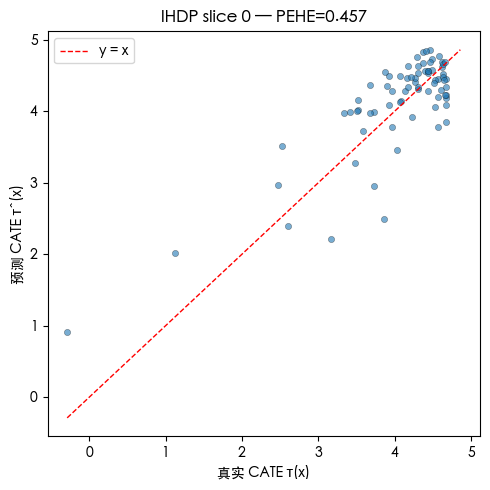

In [5]:
fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(test.cate_true, cate_pred, alpha=0.6, s=20, edgecolor="k", linewidth=0.3)
lims = [min(test.cate_true.min(), cate_pred.min()), max(test.cate_true.max(), cate_pred.max())]
ax.plot(lims, lims, "r--", linewidth=1, label="y = x")
ax.set_xlabel("真实 CATE τ(x)")
ax.set_ylabel("预测 CATE τ̂(x)")
ax.set_title(f"IHDP slice 0 — PEHE={pehe(cate_pred, test.cate_true):.3f}")
ax.legend()
plt.tight_layout()
plt.show()

## 5. 多切片批量评估

在多个 slice 上跑同一套超参，得到 PEHE 的均值和标准差（IHDP 论文标准做法）。

In [6]:
N_SLICES = 5  # 演示用，论文里通常取 100
results = []

for s in range(N_SLICES):
    tr, te = load_ihdp(DATA_DIR, slice_idx=s)
    model = GACRNet(
        num_treatments=2, hidden_dim=200, head_hidden=100,
        use_mmd=True, use_tarreg=True,
        epochs=150, batch_size=64, lr=1e-3,
        early_stopping_patience=25, verbose=False, random_state=42,
    )
    model.fit(tr.x, tr.t, tr.y)
    cate = model.estimate_cate(te.x)
    results.append({
        "slice": s,
        "pehe": pehe(cate, te.cate_true),
        "ate_err": ate_error(cate, te.cate_true),
    })
    print(f"  slice {s}: PEHE={results[-1]['pehe']:.3f}  ATE_err={results[-1]['ate_err']:.3f}")

pehes = [r["pehe"] for r in results]
ate_errs = [r["ate_err"] for r in results]
print(f"\n{N_SLICES} slices 汇总: PEHE = {np.mean(pehes):.3f} ± {np.std(pehes):.3f}")
print(f"            ATE_err = {np.mean(ate_errs):.3f} ± {np.std(ate_errs):.3f}")

  slice 0: PEHE=0.457  ATE_err=0.072
  slice 1: PEHE=0.438  ATE_err=0.180
  slice 2: PEHE=0.770  ATE_err=0.107
  slice 3: PEHE=0.810  ATE_err=0.489
  slice 4: PEHE=0.918  ATE_err=0.457

5 slices 汇总: PEHE = 0.679 ± 0.195
            ATE_err = 0.261 ± 0.177
